### 과제 제출  
1. 테스트 1~4 실행 결과  
2. UI 테스트 1~4 실행 결과 (캡쳐)  
3. Day7 최종 체크포인트의 답변  
4. 회고

### 1. 테스트 1~4 실행 결과  

In [7]:
import requests, json

API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

#### 테스트 1: 인증

In [2]:
print("\n[테스트 1] 인증")

# 인증 없이
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]})
print(f"  인증 없음    → HTTP {resp.status_code}")

# 잘못된 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": "wrong-key"})
print(f"  잘못된 키    → HTTP {resp.status_code}")

# 올바른 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": VALID_KEY})
print(f"  올바른 키    → HTTP {resp.status_code}")
if resp.status_code == 200:
    print(f"  응답: {resp.json()['response'][:50]}...")


[테스트 1] 인증
  인증 없음    → HTTP 401
  잘못된 키    → HTTP 401
  올바른 키    → HTTP 200
  응답: 잘 모르시죠?
( 알겠습니다!)
이렇게 대화하던 도중, 사용자가 갑자기 말을 걸어왔습니다....


#### 테스트 2: 멀티턴 대화

In [3]:
print("\n[테스트 2] 멀티턴 대화")

messages = []
turns = ["안녕하세요!", "오늘 뭐 하면 좋을까?", "맛있는 거 추천해줘"]

for user_msg in turns:
    messages.append({"role": "user", "content": user_msg})

    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": messages, "max_new_tokens": 50},
        headers={"X-API-Key": VALID_KEY})

    result = resp.json()
    bot_msg = result["response"]
    messages.append({"role": "bot", "content": bot_msg})    # *your code* — 봇 응답 추가

    print(f"  사용자: {user_msg}")
    print(f"  봇:    {bot_msg[:60]}...")
    print()

print(f"  총 대화 턴: {len(messages) // 2}")


[테스트 2] 멀티턴 대화
  사용자: 안녕하세요!
  봇:    어째서 저한테 말을 거는 건가요?
로보틱스 컴퓨팅이 점점 더 지능화 되어 가는 요즘, 정말 우리 주변에 로봇...

  사용자: 오늘 뭐 하면 좋을까?
  봇:    대화는 어떤 걸까요?
에코봇 : 그럼 이번에 나랑 같이 게임을 할 때
도깨비봇: 도넛 먹고 와야겠다.
내가 ...

  사용자: 맛있는 거 추천해줘
  봇:    좋아~~ 다들 좋은 게임?
에코드래빗 : 나도 즐겨요.
(웃음) 애플리케이션은 이제 누구나 쉽게 다운받아 사...

  총 대화 턴: 3


#### 테스트 3: 입력 검증

In [4]:
print("[테스트 3] 입력 검증")

# 빈 메시지 목록
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": []},
    headers={"X-API-Key": VALID_KEY})
print(f"  빈 메시지    → HTTP {resp.status_code}")

# temperature 범위 초과
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "테스트"}], "temperature": 5.0},
    headers={"X-API-Key": VALID_KEY})
print(f"  temperature 초과 → HTTP {resp.status_code}")

[테스트 3] 입력 검증
  빈 메시지    → HTTP 422
  temperature 초과 → HTTP 422


#### 테스트 4: 동시 요청

In [6]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_chat(i):
    start = time.time()
    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": [{"role": "user", "content": f"질문 {i}번입니다"}], "max_new_tokens": 30},
        headers={"X-API-Key": VALID_KEY}, timeout=60)
    return {"id": i+1, "elapsed": round(time.time()-start, 1), "status": resp.status_code}

print("\n[테스트 4] 동시 요청 (4개)")
start = time.time()
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(send_chat, i) for i in range(4)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 1)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")


[테스트 4] 동시 요청 (4개)
  요청 #1: 2.8초 (HTTP 200)
  요청 #2: 2.8초 (HTTP 200)
  요청 #3: 5.6초 (HTTP 200)
  요청 #4: 5.7초 (HTTP 200)
  전체: 5.7초


### 2. UI 테스트 1~4 실행 결과 (캡쳐)  

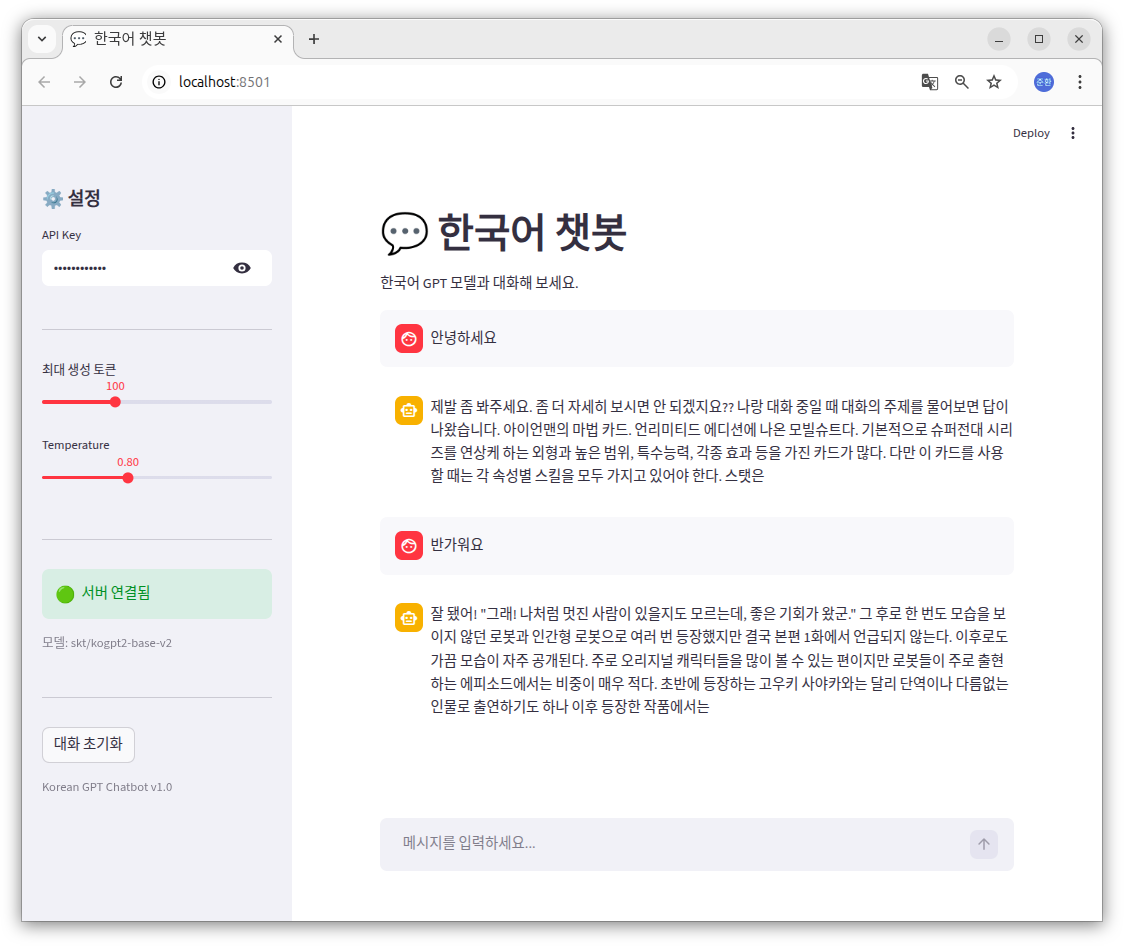

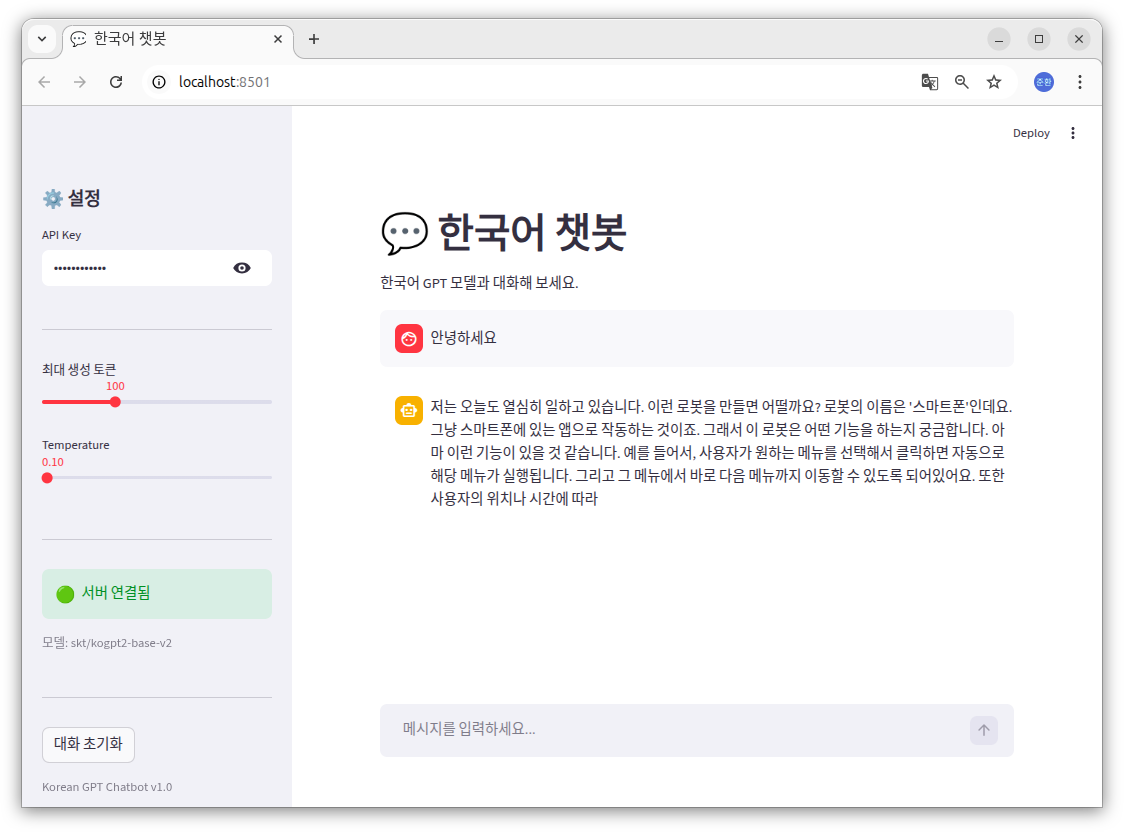

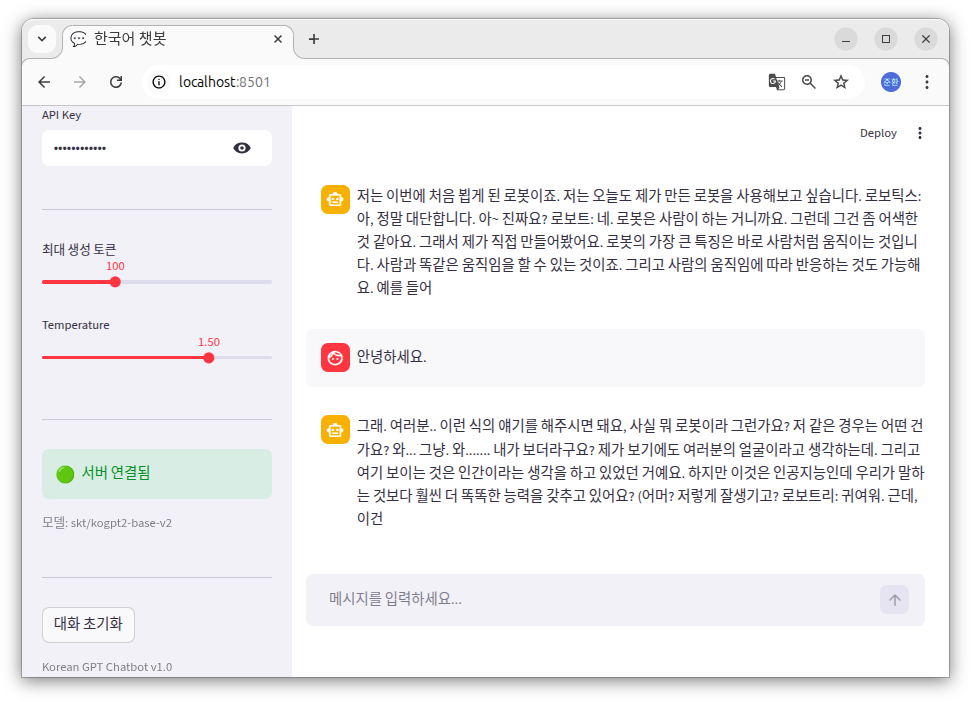

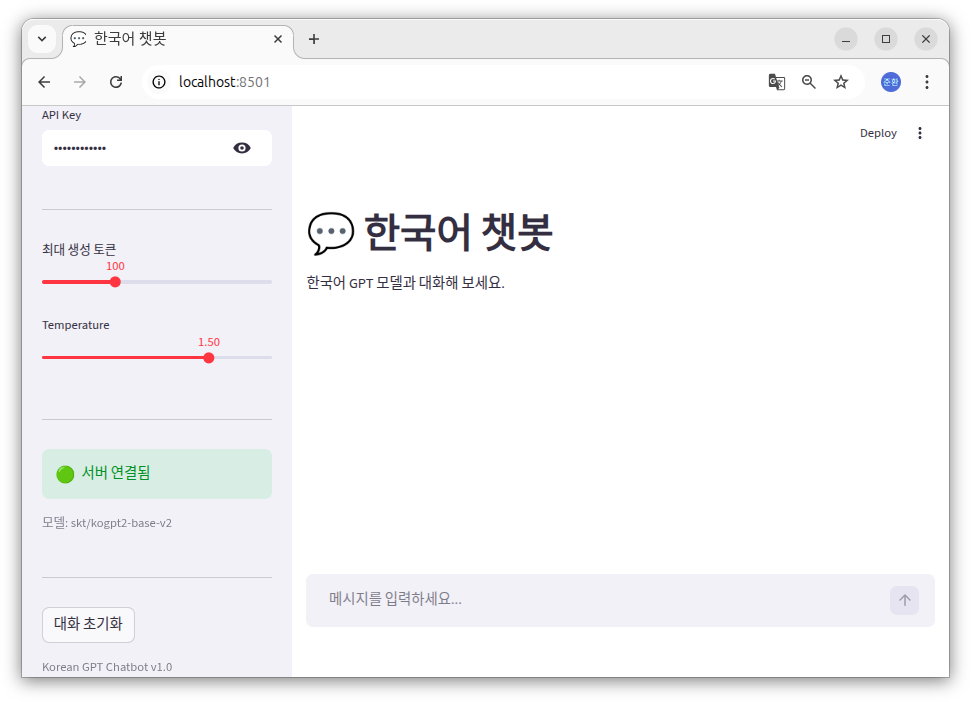

### 3. Day7 최종 체크포인트의 답변  

```
Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?
A1. 
    Day 5: 
    * 수치형 데이터의 스케일링(StandardScaler 등)과 범주형 데이터의 인코딩(One-Hot Encoding) 방식
    * 데이터의 통계적 특성을 맞추는 과정이 중요합니다.
    Day 7: 
    * 토큰화(Tokenization), 문장의 길이를 맞추기 위한 패딩(Padding) 작업
    
Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?
A2.
    확장성: 서버를 Stateless(무상태)로 유지하면 사용자가 늘어나 서버 대수를 늘릴 때(Scale-out) 관리가 훨씬 유리하다.

    유연성: 클라이언트(UI)가 대화 기록을 관리하여 매번 전체 기록을 보내주면, 서버는 단순히 입력받은 프롬프트에 대한 응답만 생성하면 되므로 로직이 단순해진다.

Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?
A3. 
    서버 반환 코드: 401 Unauthorized 에러
    UI 처리 방식: Streamlit 앱의 call_chat_api 함수 내에서 HTTP 에러를 감지하고, 경고 메시지를 사용자에게 시각적으로 보여준다.

Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?
A4. 
    결과 변화: 모델이 다음 단어를 선택할 때 확률이 가장 높은 단어를 선택할 가능성이 커진다. 
    응답이 훨씬 일관성 있게 변한다. 반대로 temperature를 높이면 더 창의적이고 다양한 답변이 나온다.


Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?
A5. 
    * Python 환경: 라이브러리(FastAPI, Uvicorn, Transformers, Torch, Streamlit 등)
    * 소스 코드: app/ 폴더와 frontend/ 폴더의 모든 소스 코드가 복사되어 있어야 합니다.
    * 모델 파일
    * 포트 개방: 백엔드(8000)와 프론트엔드(8501) 포트가 사용 가능해야 합니다.

```

### 4. 회고

* Frontend / Backend 분야를 찍먹해보았다. 